In [718]:
%load_ext autoreload
%autoreload
import jax.numpy as jnp
import jax
from jax import jit, vmap
import sys

sys.path.append("../")
import linx.const as const 
from linx.nuclear import NuclearRates
from linx.background import BackgroundModel
from linx.abundances import AbundanceModel
import linx.thermo as thermo

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline

from plot_params import params
matplotlib.pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

from scipy.integrate import quad
from scipy.interpolate import interp1d

import time


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [661]:
import linx.P_QED as P_QED

In [662]:
T = 40

In [517]:
e = jnp.sqrt(const.aFS * 4 * jnp.pi)
prefac = e**3 * T/(12 * jnp.pi**4)

p = jnp.linspace(0,50*T,num=2000) # this integral also peaks at p close to zero, integrating to 50 is fine as long as resolution is good
Ep = jnp.sqrt(p**2 + me**2)
integrand = (p**2 + Ep**2)/Ep * 2/(jnp.exp(Ep/T) + 1)

res = jnp.trapezoid(integrand,p)

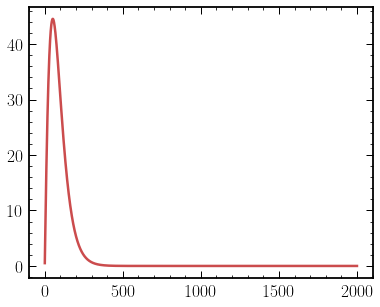

In [518]:
plt.plot(p,integrand)

In [519]:
print(jnp.trapezoid(integrand,p))
print(quad(lambda p: (p**2 + jnp.sqrt(p**2 + me**2)**2)/jnp.sqrt(p**2 + me**2) * 2/(jnp.exp(jnp.sqrt(p**2 + me**2)/T) + 1) , 0, jnp.inf)[0])

5263.633435509192
5263.65845568496


In [495]:
T = 40
me = 0.511
quad(lambda p: p**2 * jnp.log( (1 + jnp.exp(-jnp.sqrt(p**2 + me**2)/T))**2 / (1 - jnp.exp(-p/T)) ) , 0, jnp.inf)[0]

380969.1889396603

In [496]:
p = jnp.linspace(0,50*T,num=3000)
Ee = jnp.sqrt(p**2 + me**2)
integrand = p**2 * jnp.log( (1 + jnp.exp(-Ee/T))**2 / (1 - jnp.exp(-p/T)) ) 

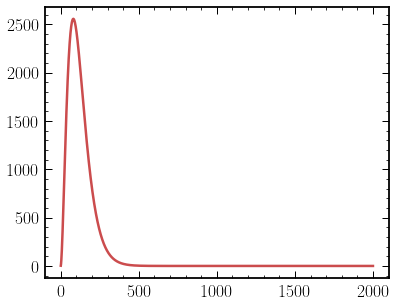

In [497]:
plt.plot(p,integrand)

In [498]:
jnp.trapezoid(jnp.nan_to_num(integrand,nan=0),p)

Array(380969.17992295, dtype=float64)

In [254]:
integrand

Array([       nan, 0.00193672, 0.00665202, ..., 0.        , 0.        ,
       0.        ], dtype=float64)

In [525]:
me = .511
T = 1.000534
print(P_QED.explicit_P0(T,me), P_QED.explicit_P2(T,me), P_QED.explicit_P3(T, me), P_QED.P_QED(T, me))

0.584374419983926 -0.0013354808639761487 0.00013392287473705834 0.5831728619946869


In [529]:
P_QED.dPdTQED_2(40.,.511)

Array(-407.48356157, dtype=float64, weak_type=True)

In [531]:
P_QED.d2PdT2QED_2(40.,.511)

Array(-30.56433696, dtype=float64, weak_type=True)

In [641]:
# Initialize the class. 
default = BackgroundModel() 

# Call the class. 
t_vec1, a_vec1, rho_g_vec1, rho_nu_vec1, _, _, Neff_vec = default(jnp.asarray(0.),me=jnp.asarray(0.5109989)) 
t_vec2, a_vec, rho_g_vec2, rho_nu_vec, _, _, Neff_vec = default(jnp.asarray(0.),me=jnp.asarray(const.me)) 

In [635]:
rho_g_vec1_interp = interp1d(t_vec1,rho_g_vec1,bounds_error=False)
rho_g_vec2_interp = interp1d(t_vec2,rho_g_vec2,bounds_error=False)

(0.2, 0.6)

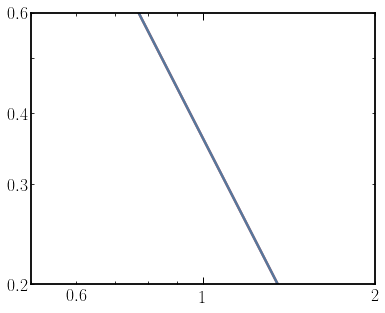

In [636]:
plt.loglog(t_vec1,rho_g_vec1)
plt.loglog(t_vec2,rho_g_vec2)
plt.xlim([0.5,2])
plt.ylim([2e-1,6e-1])

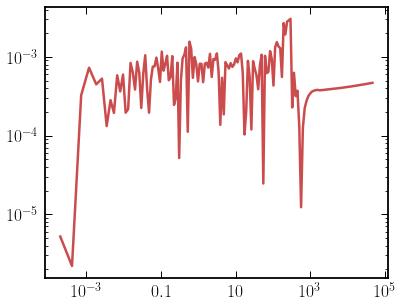

In [637]:
plt.loglog(t_vec1,jnp.abs(rho_g_vec1_interp(t_vec1)-rho_g_vec2_interp(t_vec1))/rho_g_vec2_interp(t_vec1))

In [638]:
network = 'key_PRIMAT_2023'
# network = 'key_PRIMAT_2018'
# network = 'key_PArthENoPE'
# network = 'key_YOF'
abundance_model = AbundanceModel(NuclearRates(nuclear_net=network))

In [723]:
me = jnp.asarray(0.6)

t_vec1, a_vec1, rho_g_vec1, rho_nu_vec1, _, _, Neff_vec = default(jnp.asarray(0.),me=me) 

for i in range(5):
    start = time.time()
    Planck_omega_b_res = abundance_model(
        rho_g_vec1, # photon energy density
        rho_nu_vec1, # neutrino energy density
        rho_NP_vec, # energy density of extra species
        P_NP_vec, # pressure of extra species
        t_vec=t_vec1, # vector of times at which quantities are given
        a_vec=a_vec1, # vector of scale factor at corresponding times
        eta_fac=jnp.asarray(1.), # factor by which to scale baryon-to-photon ratio
        me = me
    )
    
    print('The abundances (n_i/n_b) are: ')
    print('n:   ', Planck_omega_b_res[0])
    # print('p:   ', Planck_omega_b_res[1])
    # print('d:   ', Planck_omega_b_res[2])
    # print('t:   ', Planck_omega_b_res[3])
    # print('He3: ', Planck_omega_b_res[4])
    # print('He4: ', Planck_omega_b_res[5])
    # print('')
    # print('More standard abundances are: ')
    # print('D/H:   ', Planck_omega_b_res[2]/Planck_omega_b_res[1])
    # print('T/H:   ', Planck_omega_b_res[3]/Planck_omega_b_res[1])
    # print('He3/H: ', Planck_omega_b_res[5]/Planck_omega_b_res[1])
    # print('Yp:    ', 4*Planck_omega_b_res[5])
    # print('Li7/H: ', Planck_omega_b_res[6]/Planck_omega_b_res[1])
    print(time.time() -start)

The abundances (n_i/n_b) are: 
n:    6.79894161965725e-11
0.1366720199584961
The abundances (n_i/n_b) are: 
n:    6.79894161965725e-11
0.13133788108825684
The abundances (n_i/n_b) are: 
n:    6.79894161965725e-11
0.12949514389038086
The abundances (n_i/n_b) are: 
n:    6.79894161965725e-11
0.1299757957458496
The abundances (n_i/n_b) are: 
n:    6.79894161965725e-11
0.12741518020629883
